**DenseNet-121**
is a convolutional neural network architecture that belongs to the family of Densely Connected Dovolutional Netoworks (DenseNets). Recent work shows that ConvNets can be substantialy deeper, more accurate, and efficient to train if they contain short connections between layers close to the input and those close to the output. As time and tech improves, Conv layers gets more deeper. Short path would be needed. "short path length depends largely on the density of objects of interest". 

**DenseNet Architectures** key characteristics is the dense connectivity pattern, where each layer receives input from all preceding layers. This model attempts to solve the problem of vanishing gradients in deep CNN architectur by reusing features through a connection of each block with one another. 

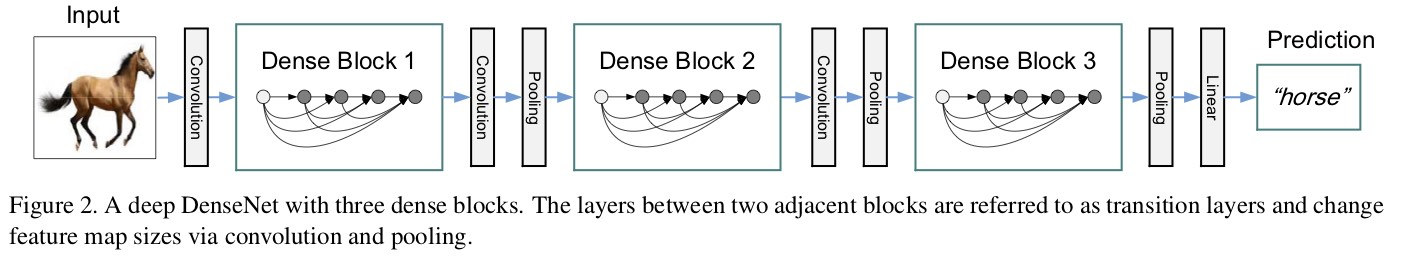


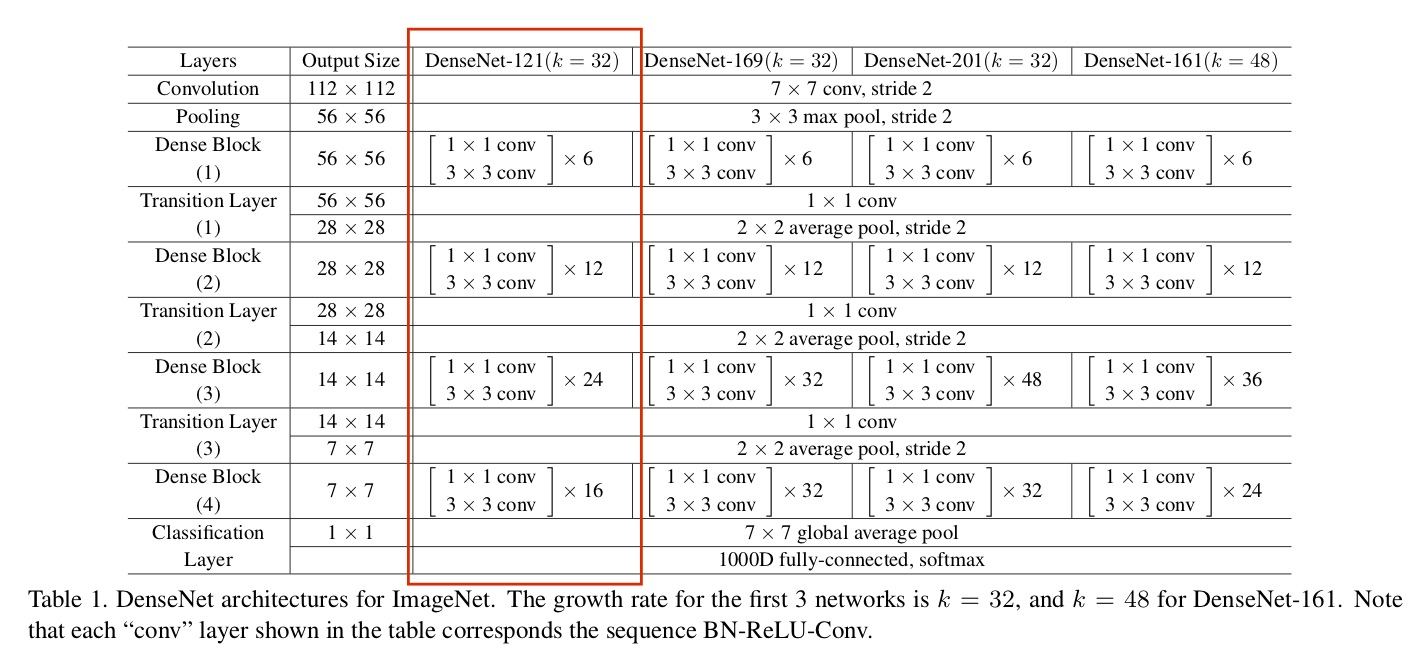

In [ ]:
import os #interact with operating system, python search for files 
import time
import random
from zipfile import ZipFile
import xml.etree.ElementTree as ET


from pathlib import Path #oop for filesystem make paths as objects
import numpy as np #array, linear algebra
from collections import OrderedDict

import torch #to import PyTorch framework
from torch import nn #nn library
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Subset
import torch.utils.checkpoint as cp
from torchvision import datasets
from torchvision import transforms #torchvision to streamline computer vision tasks in Python

import matplotlib.pyplot as plt
from PIL import Image #image modeul to represent a PIL image (PIL to load images from files + make new images)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
DATASET_DIR = Path('/data/ramialle/datasets2/Dataset_BUSI_with_GT_Clean')
IMAGE_DIR = DATASET_DIR / 'images-20260602T203626Z-3-001' / 'images'
TRAIN_XLSX = DATASET_DIR / 'train.xlsx' 
TEST_XLSX = DATASET_DIR / 'test.xlsx'

IMG_SIZE = (224, 224)
LEARNING_RATE= 0.0001
BATCH_SIZE = 128
NUM_EPOCHS = 10

CLASS_NAMES = {0: 'malignant', 1: 'benign'}
GRAYSCALE = True

print(f"The images are from {IMAGE_DIR} dataset")
print(f"We are using {DEVICE} device.")
print(f"CUDA devices: {torch.cuda.device_count()}") #returns number of GPUs available

2
The images are from /data/ramialle/datasets2/Dataset_BUSI_with_GT_Clean/images-20260602T203626Z-3-001/images dataset
We are using cuda device.
CUDA devices: 5


In [4]:
# Define a helper that converts an Excel cell reference into a numeric column index.
def _column_index(cell_reference):
    """Convert an Excel cell reference like A1 or B12 into a zero-based column index."""
    # Keep only the letters from the cell reference, such as A or AB.
    letters = ''.join(ch for ch in cell_reference if ch.isalpha())
    # Start the column index accumulator at zero.
    index = 0
    # Process each column letter from left to right.
    for char in letters:
        # Convert Excel base-26 letters into a one-based numeric column number.
        index = index * 26 + (ord(char.upper()) - ord('A') + 1)
    # Convert the one-based Excel column number into a zero-based Python index.
    return index - 1


# Define a helper that reads rows from the first worksheet of an .xlsx file.
def read_xlsx_rows(path):
    """Read the first worksheet of a simple .xlsx file into a list of dictionaries."""
    # Store the XML namespace used by Excel worksheet files.
    namespace = {'main': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

    # Open the Excel workbook as a ZIP archive.
    with ZipFile(path) as workbook_zip:
        # Create a list that will hold shared-string values from the workbook.
        shared_strings = []
        # Check whether the workbook contains a shared-string table.
        if 'xl/sharedStrings.xml' in workbook_zip.namelist():
            # Parse the shared-string XML file.
            root = ET.fromstring(workbook_zip.read('xl/sharedStrings.xml'))
            # Loop through every shared-string item.
            for item in root.findall('main:si', namespace):
                # Collect every text node belonging to this shared string.
                text_parts = [node.text or '' for node in item.findall('.//main:t', namespace)]
                # Join the text pieces and store the complete shared string.
                shared_strings.append(''.join(text_parts))

        # Parse the first worksheet XML file.
        sheet = ET.fromstring(workbook_zip.read('xl/worksheets/sheet1.xml'))
        # Create a list that will hold every worksheet row as a list of cell values.
        raw_rows = []
        # Loop through each row element inside the worksheet data.
        for row in sheet.findall('.//main:sheetData/main:row', namespace):
            # Create a list that will hold values for this row.
            values = []
            # Loop through each cell in the current row.
            for cell in row.findall('main:c', namespace):
                # Convert the cell reference, such as B3, into a zero-based column number.
                column = _column_index(cell.attrib.get('r', 'A1'))
                # Add empty placeholders until the values list reaches this cell's column.
                while len(values) <= column:
                    # Append an empty value for a missing or skipped cell.
                    values.append('')

                # Read the Excel cell type, such as shared string or inline string.
                cell_type = cell.attrib.get('t')
                # Find the standard value node for this cell.
                value_node = cell.find('main:v', namespace)
                # Find the inline-string text node for this cell, if one exists.
                inline_node = cell.find('main:is/main:t', namespace)

                # Handle cells whose value is an index into the shared-string table.
                if cell_type == 's' and value_node is not None:
                    # Look up the real text value from the shared-string list.
                    value = shared_strings[int(value_node.text)]
                # Handle cells that store text directly inside the cell.
                elif cell_type == 'inlineStr' and inline_node is not None:
                    # Use the inline text, falling back to an empty string if it is missing.
                    value = inline_node.text or ''
                # Handle ordinary cells that have a value node.
                elif value_node is not None:
                    # Use the value node text, falling back to an empty string if it is missing.
                    value = value_node.text or ''
                # Handle empty cells or unsupported cell formats.
                else:
                    # Treat missing cell content as an empty string.
                    value = ''

                # Store the resolved cell value at the correct column position.
                values[column] = value
            # Add the completed row to the raw row list.
            raw_rows.append(values)

    # Convert the first row into stripped column names.
    header = [str(value).strip() for value in raw_rows[0]]
    # Create a list that will hold one dictionary per data row.
    rows = []
    # Loop through every row after the header row.
    for row in raw_rows[1:]:
        # Pad short rows with empty strings so they match the header length.
        row = row + [''] * (len(header) - len(row))
        # Pair header names with row values to create a dictionary.
        record = dict(zip(header, row))
        # Keep only rows that contain an image filename.
        if record.get('Image'):
            # Strip whitespace from the image filename.
            record['Image'] = str(record['Image']).strip()
            # Convert the label value from Excel text/number form into an integer class id.
            record['Label'] = int(float(record['Label']))
            # Build the full filesystem path for the image.
            record['path'] = IMAGE_DIR / record['Image']
            # Add the human-readable class name for this label.
            record['class_name'] = CLASS_NAMES[record['Label']]
            # Store the cleaned record in the returned list.
            rows.append(record)
    # Return all cleaned row dictionaries.
    return rows


# Read the training split rows from the training Excel file.
train_rows = read_xlsx_rows(TRAIN_XLSX)
# Read the testing split rows from the testing Excel file.
test_rows = read_xlsx_rows(TEST_XLSX)

# Print the number of training samples found.
print(f'Training samples: {len(train_rows)}')
# Print the number of testing samples found.
print(f'Testing samples: {len(test_rows)}')
# Print the first training row as a sanity check.
print('Example training row:', train_rows[0])
# Print the first testing row as a sanity check.
print('Example testing row:', test_rows[0])

Training samples: 517
Testing samples: 130
Example training row: {'Image': 'benign (218).png', 'Label': 1, 'path': PosixPath('/data/ramialle/datasets2/Dataset_BUSI_with_GT_Clean/images-20260602T203626Z-3-001/images/benign (218).png'), 'class_name': 'benign'}
Example testing row: {'Image': 'malignant (30).png', 'Label': 0, 'path': PosixPath('/data/ramialle/datasets2/Dataset_BUSI_with_GT_Clean/images-20260602T203626Z-3-001/images/malignant (30).png'), 'class_name': 'malignant'}


In [5]:
def summarize_split(rows, split_name):
    # Extract the numeric label from every row.
    labels = [row['Label'] for row in rows]
    # Count how many examples belong to each class name.
    counts = {CLASS_NAMES[label]: labels.count(label) for label in sorted(CLASS_NAMES)}
    # Print the class-count summary for this split.
    print(f'{split_name} class counts:', counts)


# Define a helper that checks whether classification images exist.
def verify_images(rows, split_name):
    # Build a list of image paths that do not exist on disk.
    missing_images = [row['path'] for row in rows if not row['path'].exists()]
    # Stop execution if any image files are missing.
    if missing_images:
        # Raise an error showing the first missing image for easier debugging.
        raise FileNotFoundError(f'{split_name} has missing image files. First missing file: {missing_images[0]}')

    # Print a success message once all classification images are present.
    print(f'{split_name}: all classification images exist')


# Print the class distribution for the training split.
summarize_split(train_rows, 'Train')
# Print the class distribution for the testing split.
summarize_split(test_rows, 'Test')
# Verify all training images exist.
verify_images(train_rows, 'Train')
# Verify all testing images exist.
verify_images(test_rows, 'Test')


Train class counts: {'malignant': 171, 'benign': 346}
Test class counts: {'malignant': 39, 'benign': 91}
Train: all classification images exist
Test: all classification images exist


In [ ]:
train_size = len(train_rows)
train_indices = list(range(train_size))
test_indices = int((np.floor(train_size*.20)))

resize_transform = transforms.Compose([transforms.Resize(IMG_SIZE), transforms.ToTensor()])

train = datasets()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

**DenseNet121** model

In [ ]:
def _bn_function_factory(norm, relu, conv):
    def bn_function(*inputs):
        concated_features = torch.cat(inputs, 1)
        bottleneck_output = conv(relu(norm(concated_features)))
        return bottleneck_output
    
    return bn_function

class _DenseLayer(nn.Sequential):
    def __init__(self, num_input_features, growth_rate, bn_size, drop_rate, memory_efficient=False):
        super(_DenseLayer, self).__init__()
        self.add_module('norm1', nn.BatchNorm2d(num_input_features)),
        self.add_module('relu1', nn.ReLU(inplace=True)),
        self.add_module('conv1', nn.Conv2d(num_input_features, bn_size * 
                                           growth_rate, kernel_size=1, stride=1,
                                           bias=False)),
        self.add_module('norm2', nn.BatchNorm2d(bn_size * growth_rate)),
        self.add_module('relu2', nn.ReLU(inplace=True)),
        self.add_module('conv2', nn.Conv2d(bn_size * growth_rate, growth_rate,
                                           kernel_size=3, stride=1, padding=1
                                           bias=False)),
        self.drop_rate = drop_rate
        self.memory_efficient = memory_efficient

    def forward(self, *prev_features):
        bn_function = _bn_function_factory(self.norm1, self.relu1, self.conv1)
        if self.memory_efficient and any(prev_feature.requires_grad for prev_feature in prev_features):
            bottleneck_output = cp.checkpoint(bn_function, *prev_features)
        else:
            bottleneck_output = bn_function(*prev_features)
        new_features = self.conv2(self.relu2(self.norm2(bottleneck_output)))
        if self.drop_rate > 0:
            new_features = F.dropout(new_features, p=self.drop_rate,
                                     training=self.training)
            return new_features
        
class _DenseBlock(nn.Module):
    def __init__(self, num_layers, num_input_features, bn_size, growth_rate, drop_rate, memory_efficient=False):
        super(_DenseBlock, self).__init__()
        for i in range(num_layers):
            layer = _DenseLayer(
                num_input_features + i * growth_rate,
                growth_rate=growth_rate,
                bn_size=bn_size,
                drop_rate=drop_rate,
                memory_efficient=memory_efficient
            )
            self.add_module('denselayer%d' % (i + 1), layer)

    def forward(self, init_features):
        features = [init_features]
        for name, layer in self.named_children():
            new_features = layer(*features)
            features.append(new_features)
        return torch.cat(features, 1)
    
class _Transition(nn.Sequential):
    def __init__(self, num_input_features, num_output_features):
        super(_Transition, self).__init__()
        self.add_module('norm', nn.BatchNorm2d(num_input_features))
        self.add_module('relu', nn.ReLU(inplace=True))
        self.add_module('conv', nn.Conv2d(num_input_features, num_output_features,
                                          kernel_size=1, stride=1, bias=False))
        self.add_module('pool', nn.AvgPool2d(kernel_size=2, stride=2))

class DenseNet121(nn.Module):
    """
    Args:
        growth_rate (int) - how many filters to add each layer ('k' in paper)
        block_config(list of 4 ints) - how many layers in each pooling block
        num_init_featuremaps (int) - the number of filters to learn in the first convolution layer
        bn_size (int) - multiplicative factor for number of bottle neck layerss
            (i.e. bn_size * k features in the bottleneck layer)
            drop_rate (float) - dropout rate after each dense layer
            num_classes (int) - number of classification classes
            memory_efficient (bool) - If True, uses checkpointing. Much more memory efficient,
            but slower. Default: *False*
    """

    def __init__(self, growth_rate=32, block_config=(6, 12, 24, 16),
                 num_init_featuremaps=64, bn_size=4, drop_rate=0, num_classes=1000, memory_efficient=False,
                 grayscale=False):
        
        super(DenseNet121, self).__init__()

        # First convolution
        if grayscale:
            in_channels=1
        else:
            in_channels=3

        self.features = nn.Sequential(OrderedDict([
            ('conv0', nn.Conv2d(in_channels=in_channels, out_channels=num_init_featuremaps,
                                kernel_size=7, stride=2,
                                padding=3, bias=False)),
            ('norm0', nn.BatchNorm2d(num_features=num_init_featuremaps)),
            ('relu0', nn.ReLU(inplace=True)),
            ('pool0', nn.MaxPool2d(kernel_size=3, stride=2, padding=1)),
        ]))

        num_features = num_init_featuremaps
        for i, num_layers in enumerate(block_config):
            block = _DenseBlock(
                num_layers=num_layers,
                num_input_features=num_features,
                bn_size=bn_size,
                drop_rate=drop_rate,
                memory_efficient=memory_efficient
            )
            self.features.add_module('denseblock%d' % (i + 1), block)
            num_features = num_features + num_layers * growth_rate
            if i != len(block_config) - 1:
                trans = _Transition(num_input_features=num_features,
                                    num_output_features=num_features // 2)
                self.features.add_module('transition%d' % (i + 1), trans)
                num_features = num_features // 2
        self.features.add_module('norm5', nn.BatchNorm2d(num_features))

        self.classifier = nn.Linear(num_features, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal(m.weight)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.constant_(m.bias, 0)

    def forward (self, x):
        features = self.features(x)
        out = F.adaptive_avg_pool2d(out, (1,1))
        out = torch.flatten(out, 1)
        logits = self.classifier(out)
        probas = F.softmax(logits, dim=1)
        return logits, probas    

In [ ]:
model = DenseNet121(num_classes=len(CLASS_NAMES, grayscale=GRAYSCALE))